In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Set plotting styles
plt.style.use("ggplot")
sns.set_style("whitegrid")

          ds    y
0 2020-01-04  0.0
1 2020-01-05  0.0
2 2020-01-06  0.0
3 2020-01-07  0.0
4 2020-01-08  0.0
                        ds              y
count                 2312    2312.000000
mean   2023-03-04 12:00:00   19488.308824
min    2020-01-04 00:00:00       0.000000
25%    2021-08-03 18:00:00       0.000000
50%    2023-03-04 12:00:00     197.000000
75%    2024-10-02 06:00:00   13195.500000
max    2026-05-03 00:00:00  414188.000000
std                    NaN   53960.942632
Total Rows: 2312
Start Date: 2020-01-04 00:00:00
End Date: 2026-05-03 00:00:00
Maximum Daily Cases: 414188.0
Mean Daily Cases: 19488.308823529413


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/plots/daily_cases.png'

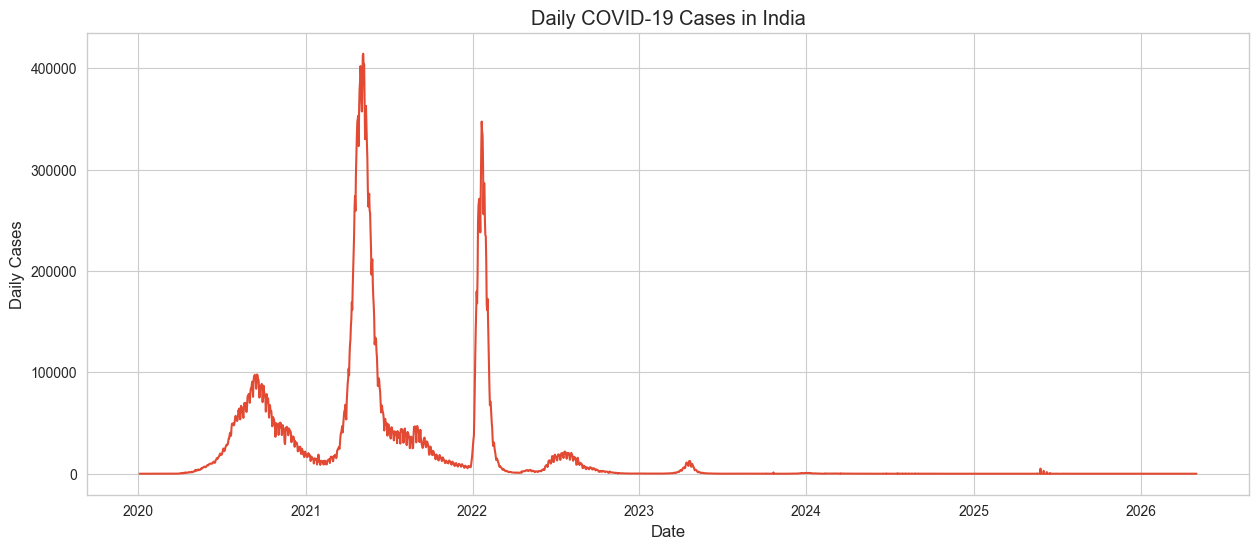

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Set plotting styles
plt.style.use("ggplot")
sns.set_style("whitegrid")

# Load cleaned dataset
df = pd.read_csv("../data/processed/india_covid_clean.csv")

# Convert date column
df["ds"] = pd.to_datetime(df["ds"])

# Inspect dataset
print(df.head())
print(df.describe())

# Basic dataset overview
print("Total Rows:", len(df))
print("Start Date:", df["ds"].min())
print("End Date:", df["ds"].max())
print("Maximum Daily Cases:", df["y"].max())
print("Mean Daily Cases:", df["y"].mean())

# ----------------------------
# Plot daily trend
# ----------------------------
plt.figure(figsize=(15, 6))
plt.plot(df["ds"], df["y"])
plt.title("Daily COVID-19 Cases in India")
plt.xlabel("Date")
plt.ylabel("Daily Cases")

plt.savefig("../outputs/plots/daily_cases.png", dpi=300, bbox_inches="tight")
plt.show()

# ----------------------------
# 7-day rolling average
# ----------------------------
df["7_day_avg"] = df["y"].rolling(window=7).mean()

plt.figure(figsize=(15, 6))
plt.plot(df["ds"], df["y"], alpha=0.4, label="Daily Cases")
plt.plot(df["ds"], df["7_day_avg"], linewidth=3, label="7-Day Average")
plt.title("COVID-19 Cases with Rolling Average")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.legend()

plt.savefig("../outputs/plots/rolling_avg.png", dpi=300, bbox_inches="tight")
plt.show()

# ----------------------------
# Interactive Plotly chart
# ----------------------------
fig = px.line(
    df,
    x="ds",
    y="y",
    title="Interactive COVID-19 Trend"
)
fig.show()

# ----------------------------
# Top peak days
# ----------------------------
top_days = df.nlargest(10, "y")
print(top_days[["ds", "y"]])

# ----------------------------
# Growth rate
# ----------------------------
df["growth_rate"] = df["y"].pct_change() * 100

plt.figure(figsize=(15, 6))
plt.plot(df["ds"], df["growth_rate"])
plt.title("COVID-19 Growth Rate")
plt.xlabel("Date")
plt.ylabel("Growth Rate (%)")

plt.savefig("../outputs/plots/growth_rate.png", dpi=300, bbox_inches="tight")
plt.show()

# ----------------------------
# Monthly aggregation
# ----------------------------
df = df.set_index("ds")

monthly_cases = df["y"].resample("ME").sum()

plt.figure(figsize=(15, 6))
monthly_cases.plot(kind="bar")

plt.title("Monthly COVID Cases")
plt.xlabel("Month")
plt.ylabel("Cases")

plt.savefig("../outputs/plots/monthly_cases.png", dpi=300, bbox_inches="tight")
plt.show()

# ----------------------------
# Correlation heatmap
# ----------------------------
corr = df[["y", "7_day_avg", "growth_rate"]].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.savefig("../outputs/plots/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# ----------------------------
# Outlier detection
# ----------------------------
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["y"])

plt.title("Outlier Detection")
plt.xlabel("Daily Cases")

plt.savefig("../outputs/plots/outliers.png", dpi=300, bbox_inches="tight")
plt.show()

# ----------------------------
# Distribution analysis
# ----------------------------
plt.figure(figsize=(10, 5))
sns.histplot(df["y"], bins=50, kde=True)

plt.title("Distribution of Daily COVID Cases")
plt.xlabel("Daily Cases")
plt.ylabel("Frequency")

plt.savefig("../outputs/plots/distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# ----------------------------
# Country comparison
# ----------------------------
raw_df = pd.read_csv("../data/raw/who_covid_data.csv")
raw_df["Date_reported"] = pd.to_datetime(raw_df["Date_reported"])

countries = ["India", "United States", "Brazil"]

comparison_df = raw_df[raw_df["Country"].isin(countries)]

comparison_df = comparison_df.groupby(
    ["Date_reported", "Country"]
)["New_cases"].sum().reset_index()

plt.figure(figsize=(15, 6))

for c in countries:
    temp = comparison_df[comparison_df["Country"] == c]
    plt.plot(temp["Date_reported"], temp["New_cases"], label=c)

plt.title("COVID-19 Daily Cases Comparison")
plt.xlabel("Date")
plt.ylabel("Daily Cases")
plt.legend()

plt.savefig("../outputs/plots/country_comparison.png", dpi=300, bbox_inches="tight")
plt.show()